# 1. Постановка задачи

## 1.1 Что это за данные
В данном исследовании используется датасет `Attribute_DataSet.csv`, содержащий подробную информацию о характеристиках женских платьев, их дизайне, материалах и истории продаж. Набор данных включает 500 записей (строк) и 15 признаков (столбцов), среди которых представлены числовые, категориальные и временные данные. Датасет отражает параметры ассортимента одежды, включая цены, размеры, рейтинги, сезонность и даты приобретения.

## 1.2 Условный заказчик анализа
В качестве условного заказчика анализа выступает **отдел маркетинга и управления продуктом интернет-магазина одежды**. Заинтересованными лицами также являются менеджеры по закупкам и команда аналитиков данных, перед которыми стоит задача оптимизации товарной матрицы и повышения продаж.

## 1.3 Возможные задачи интеллектуального анализа данных (ИАД)
С помощью данного датасета планируется решать следующие задачи:
- **Классификация и прогнозирование успешности товара (`Recommendation`):** Построение предсказательных моделей, определяющих по характеристикам платья (стиль, цена, материал), будет ли товар пользоваться спросом у покупателей.
- **Описательная аналитика и профилирование групп:** Поиск скрытых закономерностей, анализ предпочтений аудитории в зависимости от сезона, ценовой категории и стиля, а также выявление наиболее успешных комбинаций признаков одежды.

# 2. Паспорт датасета

 Определим размерность датасета, проведем анализ типов данных каждого признака и приведение их к корректным типам.

In [19]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/Attribute_DataSet.csv')

num_rows, num_cols = df.shape
print(f"Кол-во строк: {num_rows}")
print(f"Кол-во столбцов: {num_cols}\n")

Кол-во строк: 500
Кол-во столбцов: 15



In [20]:
print("Признаки")

df.info()

df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'])

Признаки
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Dress_ID        500 non-null    int64  
 1   Style           500 non-null    object 
 2   Price           498 non-null    object 
 3   Rating          500 non-null    float64
 4   Size            500 non-null    object 
 5   Season          498 non-null    object 
 6   NeckLine        497 non-null    object 
 7   SleeveLength    498 non-null    object 
 8   waiseline       413 non-null    object 
 9   Material        372 non-null    object 
 10  FabricType      234 non-null    object 
 11  Decoration      264 non-null    object 
 12  Pattern Type    391 non-null    object 
 13  Recommendation  500 non-null    int64  
 14  Purchase_Date   500 non-null    object 
dtypes: float64(1), int64(2), object(12)
memory usage: 58.7+ KB


# 3. Аудит качества данных

### 3.1. Пропуски

Проводем проверку датасета на наличие пропущенных значений, дубликатов записей, «грязных» категорий и выбросов в числовых признаках.

In [22]:
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Количество пропусков': missing_count,
    'Доля (%)': missing_percent
})

print("Пропуски в данных")
display(missing_df[missing_df['Количество пропусков'] > 0].sort_values(by='Количество пропусков', ascending=False))

Пропуски в данных


,Количество пропусков,Доля (%)
FabricType,266,53.2
Decoration,236,47.2
Material,128,25.6
Pattern Type,109,21.8
waiseline,87,17.4
NeckLine,3,0.6
Price,2,0.4
SleeveLength,2,0.4
Season,2,0.4


Наиболее проблемные признаки: FabricType (53.2% пропусков), Decoration (47.2%), Material (25.6%) и waiseline (17.4%). В то же время такие поля, как Price, Season, NeckLine и SleeveLength, имеют единичные пропуски (меньше 1%).

Главные проблемы (FabricType, Material): В этих колонках пропущено очень много данных (больше половины). Если просто удалить все пустые строки, мы потеряем больше половины нашего датасета. Поэтому лучше заменить пустые места словом 'Unknown' (неизвестно) или вообще не использовать эти колонки в расчетах.

Мелкие пропуски (Price, Season): Здесь пропусков всего по 1–2 штуки — это совсем не страшно. Их можно либо просто удалить, либо заменить самым популярным значением (например, если чаще всего встречается летний сезон, поставить его).

### 3.2. Дубликаты

In [24]:
full_duplicates = df.duplicated().sum()
id_duplicates = df['Dress_ID'].duplicated().sum()

print(f"Кол-во полностью дублирующихся строк: {full_duplicates}")
print(f"Кол-о повторяющихся id (Dress_ID): {id_duplicates}")

Кол-во полностью дублирующихся строк: 0
Кол-о повторяющихся id (Dress_ID): 25


### 3.3. Типические проблемы значений

In [ ]:
print("Статистика числовых признаков")
print(df[['Rating', 'Recommendation']].describe())

print("\nАнализ уникальных значений")
print("Price:", df['Price'].unique())
print("Size:", df['Size'].unique())
print("Season:", df['Season'].unique())

Статистика числовых признаков
           Rating  Recommendation
count  500.000000      500.000000
mean     3.528600        0.420000
std      2.005364        0.494053
min      0.000000        0.000000
25%      3.700000        0.000000
50%      4.600000        0.000000
75%      4.800000        1.000000
max      5.000000        1.000000

Анализ уникальных значений
Price: ['Low' 'High' 'Average' 'Medium' 'very-high' 'low' 'high' nan]
Size: ['M' 'L' 'XL' 'free' 'S' 'small' 's']
Season: ['Summer' 'Automn' 'Spring' 'Winter' 'spring' 'winter' nan 'summer'
 'Autumn']


Числовой признак Rating: Минимальное значение равно 0.0, максимальное — 5.0. Значения 0.0 скорее всего, это закодированные пропуски или отсутствие оценок, а не реальный нулевой рейтинг.

Категориальные признаки («грязные данные»):

В колонке Price есть дублирование из-за разного регистра: присутствуют как 'Low', так и 'low', а также 'High' и 'high'.

В колонке Size есть смесь форматов: заглавные (M, L, XL, S), строчные (small, s) и текстовое значение (free).

В колонке Season есть разнобой по регистру (Summer / summer, Automn / Autumn / spring).

### 3.4. Выбросы

In [60]:
rating = df['Rating'].replace(0, np.nan).dropna()

Q1 = rating.quantile(0.25)
Q3 = rating.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = rating[(rating < lower) | (rating > upper)]
print(f'Q1={Q1}, Q3={Q3}, IQR={IQR}')
print(f'Границы: [{lower:.2f}; {upper:.2f}]')
print(f'Кол-во выбросов: {len(outliers)} ({len(outliers)/len(rating)*100:.2f}%)')
print(outliers.value_counts().sort_index())

Q1=4.5, Q3=4.8, IQR=0.2999999999999998
Границы: [4.05; 5.25]
Кол-во выбросов: 13 (3.42%)
Rating
1.0    1
3.0    1
3.5    1
3.6    1
3.7    2
4.0    7
Name: count, dtype: int64


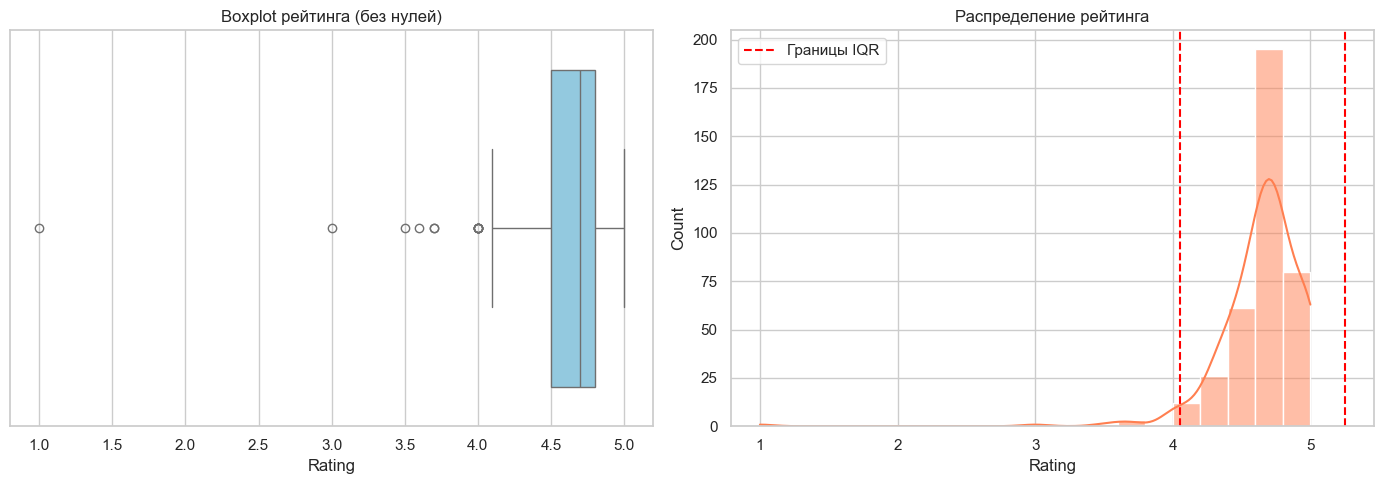

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x=rating_valid, ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot рейтинга (без нулей)')

sns.histplot(rating_valid, bins=20, kde=True, ax=axes[1], color='coral')
axes[1].axvline(lower, color='red', linestyle='--', label='Границы IQR')
axes[1].axvline(upper, color='red', linestyle='--')
axes[1].set_title('Распределение рейтинга')
axes[1].legend()
plt.tight_layout()
plt.show()

Вывод: выбросы — это низкие оценки (3.0–3.7), которые не являются ошибками, а отражают реальное недовольство покупателей. Их не следует удалять, но стоит учитывать при моделировании (например, при анализе рекомендаций).

## 4. Разведочный анализ

В этом разделе мы исследуем распределения признаков, оценим популярность различных категорий товаров (стили, сезоны, цены) и найдем ключевые закономерности, влияющие на рекомендации и рейтинги платьев.

C:\Users\Миша\AppData\Local\Temp\ipykernel_15880\1555206249.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_styles.values, y=top_styles.index, palette='Blues_r')


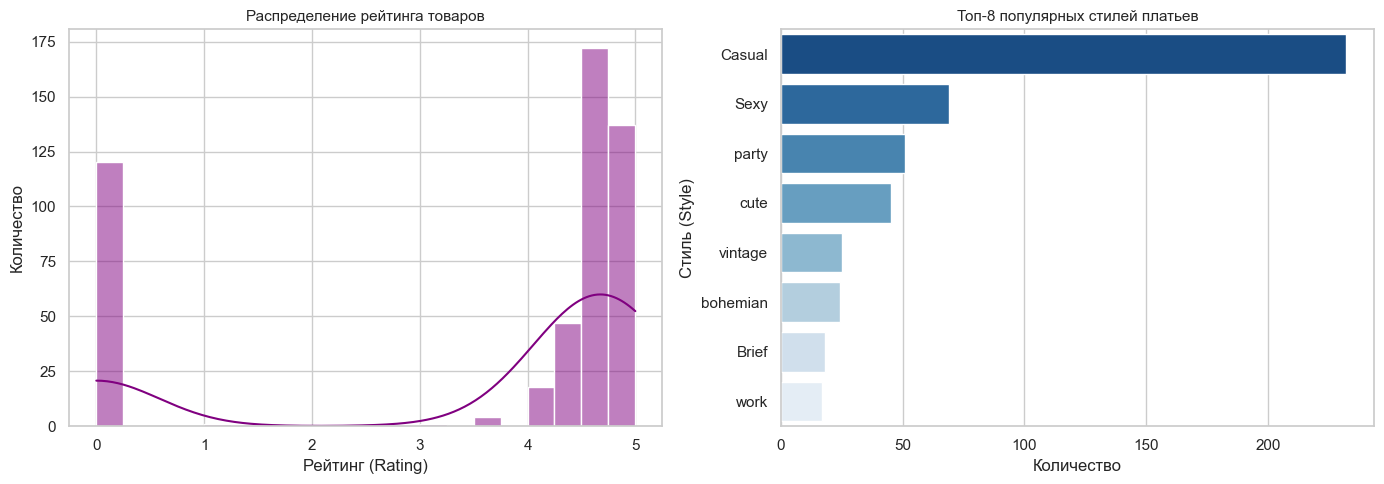

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Rating'], bins=20, kde=True, color='purple')
plt.title('Распределение рейтинга товаров', fontsize=11)
plt.xlabel('Рейтинг (Rating)')
plt.ylabel('Количество')

plt.subplot(1, 2, 2)
top_styles = df['Style'].value_counts().head(8)
sns.barplot(x=top_styles.values, y=top_styles.index, palette='Blues_r')
plt.title('Топ-8 популярных стилей платьев', fontsize=11)
plt.xlabel('Количество')
plt.ylabel('Стиль (Style)')

plt.tight_layout()
plt.show()

# График 1

Что видно: распределение Rating резко смещено влево к нулю — большая часть значений равна 0.0 (это маркер отсутствия оценки, а не реальный рейтинг). Среди ненулевых значений пик приходится на диапазон 4.4–4.8, что говорит о преимущественно высоких оценках.

Гипотезы: ноль в Rating — это не оценка, а пропуск. Если заменить 0 на NaN, распределение станет узким и смещённым к 4.5. Низкие оценки (1.0–3.7) — редкие, но значимые.

Вопросы: Можно ли предсказать реальный рейтинг товара с rating = 0 по остальным признакам?

# График 2

Что видно: категория Casual доминирует — почти половина всех платьев. Далее идут Sexy, vintage, Brief, cute, bohemian, party, work.

Гипотезы: датасет смещён в сторону повседневных платьев; остальные стили представлены слабо.

Вопросы: есть ли связь между стилем и рейтингом? Получают ли party-платья более высокие оценки, чем Casual?